# Latent Space Visualizations with Autoencoders on CIFAR-10

1. Train a convolutional autoencoder.
2. Extract the encoder's latent vectors.
3. Visualize those latent vectors with PCA, t-SNE, and UMAP.
4. Interpret what the plots do - and do not - tell us.
5. Explore reconstructions and latent interpolation.

The main idea is that an autoencoder learns an encoder-decoder pair: the encoder compresses an image into a lower-dimensional latent representation, and the decoder tries to reconstruct the original image from that representation.

## PCA, t-SNE, and UMAP: what are we visualizing?

Latent vectors usually have more than two dimensions, so we need dimensionality reduction to plot them.

**PCA** is linear. It finds directions that explain the most variance. The axes are meaningful as principal components, and the explained variance ratio tells us how much information is captured by the plotted dimensions.

**t-SNE** is nonlinear and focuses on preserving local neighborhoods. Nearby points in a t-SNE plot are usually meaningful, but distances between far-away clusters and cluster sizes can be misleading.

**UMAP** is also nonlinear. It is often faster than t-SNE and can preserve more global structure, but its appearance still depends strongly on parameters such as `n_neighbors` and `min_dist`.

In short: use these plots to form hypotheses, not as final proof of class separation.

### Import Libraries

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn as nn
import torch.nn.functional as F


### Download & Load Dataset

In [2]:
#Converting data to torch.FloatTensor
transform = transforms.ToTensor()

# Download the training and test datasets
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, num_workers=0)

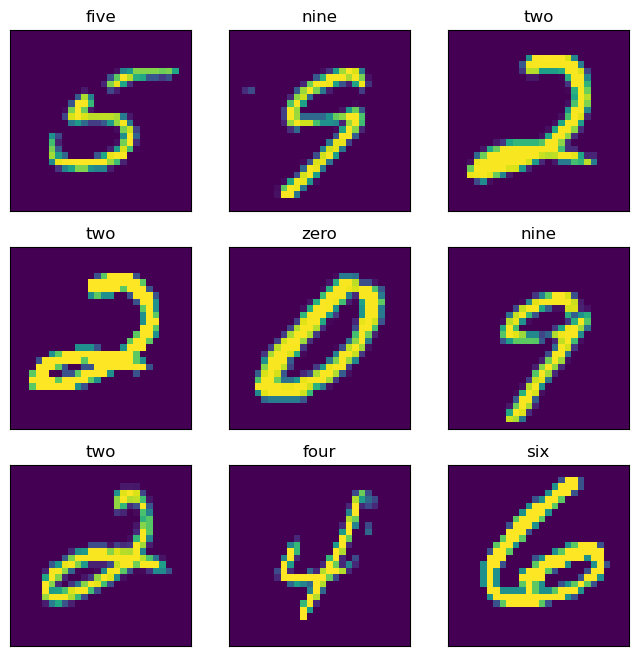

In [3]:
#Utility functions to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  
    plt.imshow(np.transpose(img, (1, 2, 0))) 

 
#Define the image classes
classes = ['zero','one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

#Obtain one batch of training images
dataiter = iter(train_loader)
#images, labels = dataiter
 # convert images to numpy for display
for images, labels in dataiter:
    images = images.numpy()
#Plot the images
fig = plt.figure(figsize=(8, 8))
# display 20 images
for idx in np.arange(9):
    ax = fig.add_subplot(3, 3, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

## Define a convolutional autoencoder

The encoder progressively downsamples the image and produces a latent vector. The decoder mirrors this process and upsamples the latent vector back to an image.

In [4]:
#Define the Convolutional Autoencoder
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
       
        #Encoder
        self.encoder = nn.Sequential(
           nn.Conv2d(1, 16, kernel_size=3, padding=1),
           nn.BatchNorm2d(16),
           nn.ReLU(),
           nn.MaxPool2d(2),

           nn.Conv2d(16, 8, kernel_size=3, padding=1),
           nn.BatchNorm2d(8),
           nn.ReLU(),
           nn.MaxPool2d(2),

           nn.Conv2d(8, 4, kernel_size=3, padding=1),
           nn.BatchNorm2d(4),
           nn.ReLU(),
       )
        
        self.decoder = nn.Sequential(

           nn.Conv2d(4, 8, kernel_size=3, padding=1),
           nn.BatchNorm2d(8),
           nn.ReLU(),

           nn.ConvTranspose2d(8, 16, kernel_size=2, stride=2),
           nn.BatchNorm2d(16),
           nn.ReLU(),

           nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
           nn.Sigmoid(),
       )


    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
              
        return x


#Instantiate the model
model = ConvAutoencoder()
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(8, 16, kernel_size=(2, 2

## Train the autoencoder

The reconstruction loss compares the original image with the reconstructed image. Here we use mean squared error.

A bottleneck prevents the model from simply copying all pixels directly. It must learn a compressed representation useful for reconstruction.

In [5]:
#Loss function
criterion = nn.BCELoss()

#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def get_device():
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return device

device = get_device()
print(device)
model.to(device)
#Epochs
n_epochs = 100 #increase this number if possible
PATH = '' # path where weights need to be saved
for epoch in range(1, n_epochs+1):
    # monitor training loss
    train_loss = 0.0

    #Training
    for data in train_loader:
        images, _ = data
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*images.size(0)
          
    train_loss = train_loss/len(train_loader)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))
torch.save(model.state_dict(), 'weights.pt')


cuda:0
Epoch: 1 	Training Loss: 4.359079
Epoch: 2 	Training Loss: 2.577913
Epoch: 3 	Training Loss: 2.503754
Epoch: 4 	Training Loss: 2.468149
Epoch: 5 	Training Loss: 2.446092
Epoch: 6 	Training Loss: 2.430656
Epoch: 7 	Training Loss: 2.418168
Epoch: 8 	Training Loss: 2.407194
Epoch: 9 	Training Loss: 2.398066
Epoch: 10 	Training Loss: 2.390068
Epoch: 11 	Training Loss: 2.382505
Epoch: 12 	Training Loss: 2.374872
Epoch: 13 	Training Loss: 2.367660
Epoch: 14 	Training Loss: 2.360841
Epoch: 15 	Training Loss: 2.354648
Epoch: 16 	Training Loss: 2.349262
Epoch: 17 	Training Loss: 2.344716
Epoch: 18 	Training Loss: 2.340672
Epoch: 19 	Training Loss: 2.337074
Epoch: 20 	Training Loss: 2.333351
Epoch: 21 	Training Loss: 2.330183
Epoch: 22 	Training Loss: 2.327480
Epoch: 23 	Training Loss: 2.325188
Epoch: 24 	Training Loss: 2.323074
Epoch: 25 	Training Loss: 2.321134
Epoch: 26 	Training Loss: 2.319119
Epoch: 27 	Training Loss: 2.317154
Epoch: 28 	Training Loss: 2.315309
Epoch: 29 	Training Lo

## Inspect reconstructions

Reconstructions reveal what the latent code preserves. If the model has learned useful compressed features, reconstructions should keep coarse color, shape, and object layout.

/tmp/ipykernel_3753825/2375430159.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_pretrained = torch.load(local_path, map_location='cpu')


Original Images


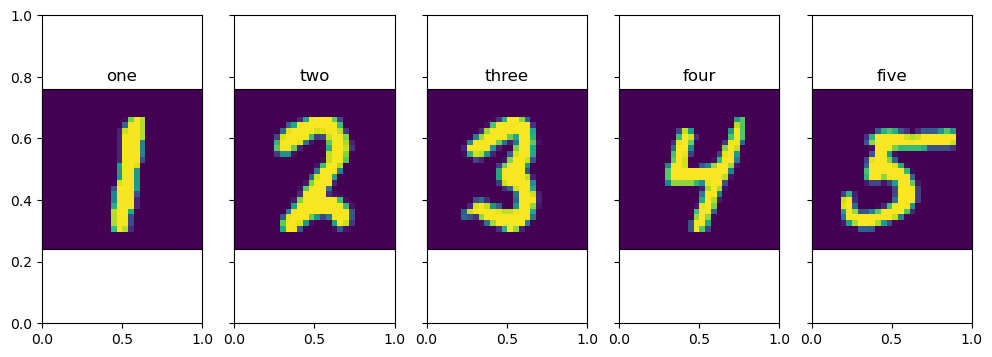

Reconstructed Images


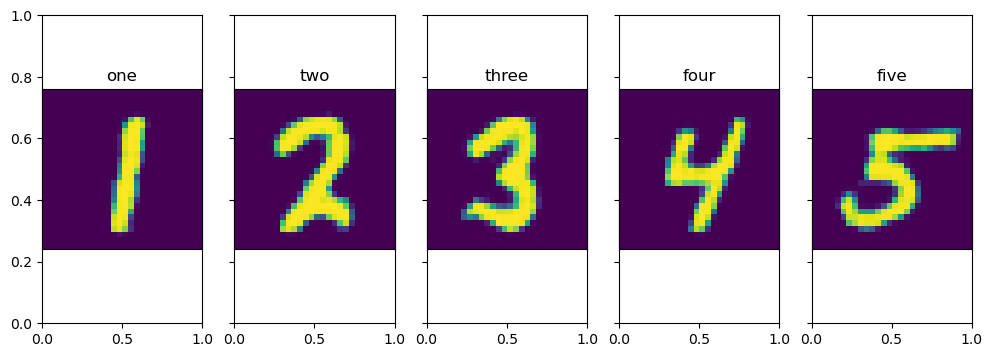

In [6]:
local_path = "weights.pt"  # path to the weights.pt file 
weights_pretrained = torch.load(local_path, map_location='cpu')
model.load_state_dict(weights_pretrained)
model.eval()
#Batch of test images
dataiter = iter(test_loader)
#images, labels = dataiter.next()
for images, labels in dataiter:
    images = images.cuda()
    labels = labels.cuda()
batch_size=16
#Sample outputs
output = model(images)
images = images.cpu().numpy()
output = output.view(batch_size, 1, 28, 28)
output = output.cpu().detach().numpy()

#Original Images
print("Original Images")
fig, axes = plt.subplots(nrows=1, ncols=5, sharex=True, sharey=True, figsize=(12,4))
for idx in np.arange(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])
plt.show()

#Reconstructed Images
print('Reconstructed Images')
fig, axes = plt.subplots(nrows=1, ncols=5, sharex=True, sharey=True, figsize=(12,4))
for idx in np.arange(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    imshow(output[idx])
    ax.set_title(classes[labels[idx]])
plt.show() 

### Extract Latent Features

In [7]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

features = []
labels_all = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        model = model.cuda()
        encoded = model.encoder(data)
        encoded = encoded.view(encoded.size(0), -1)

        features.append(encoded.cpu().numpy())
        labels_all.append(labels.cpu().numpy())

features = np.concatenate(features, axis=0)
labels_all = np.concatenate(labels_all, axis=0)

print(features.shape)

(10000, 196)


### PCA

Explained variance: [0.16301735 0.10342181]
Total explained: 0.26643917


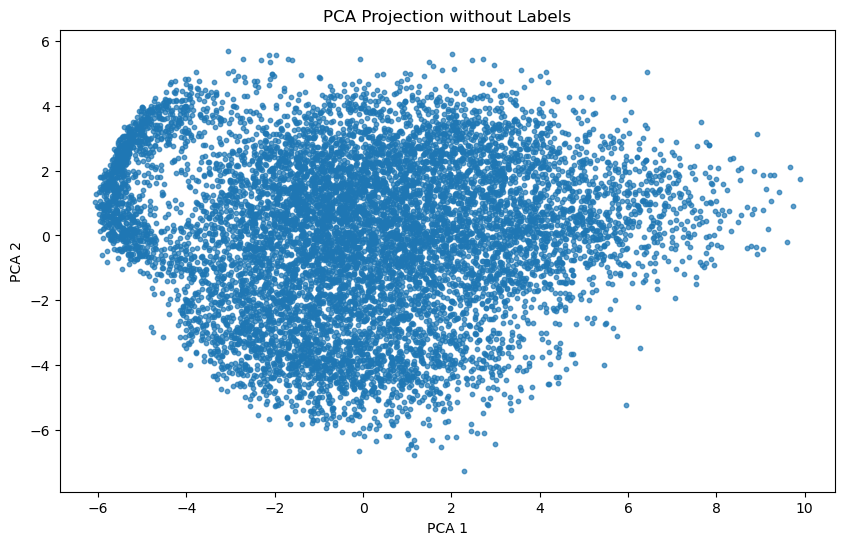

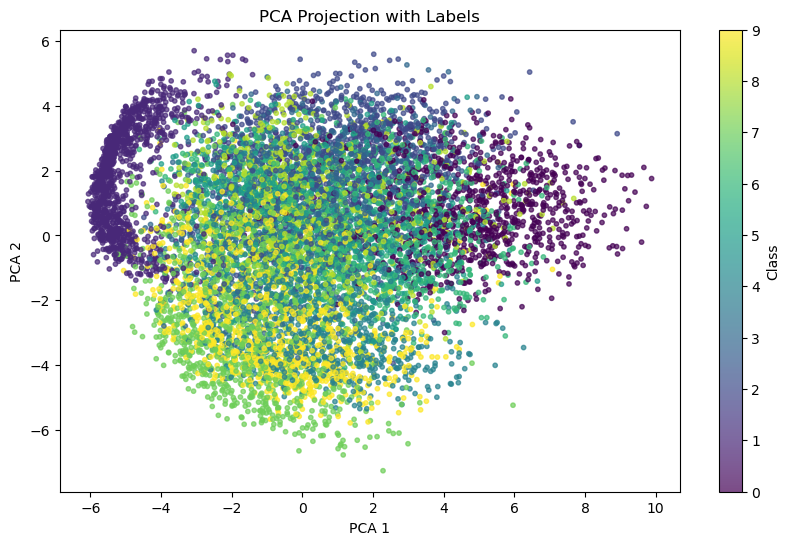

In [8]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 6))
plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    s=10,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection without Labels")
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=labels_all,
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection with Labels")
plt.colorbar(scatter, label="Class")
plt.show()

T-SNE PLot

/tmp/ipykernel_3753825/333106919.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(tsne_features[:, 0], tsne_features[:, 1], cmap='viridis')


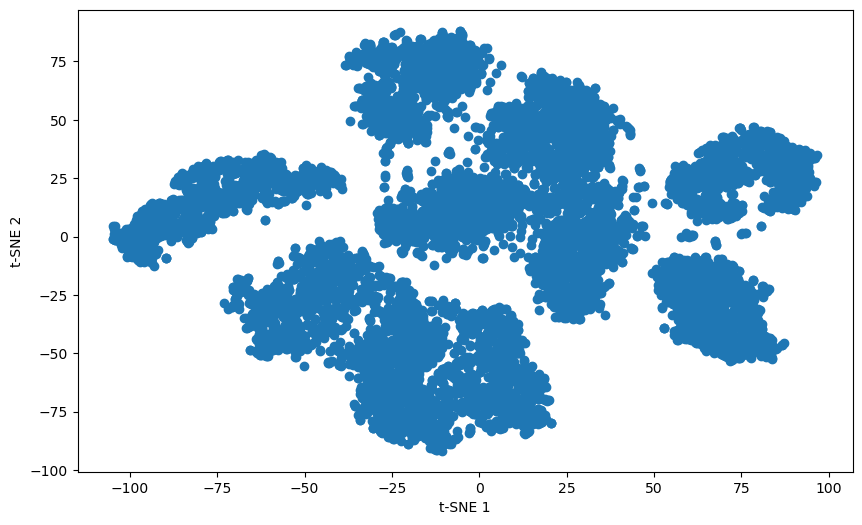

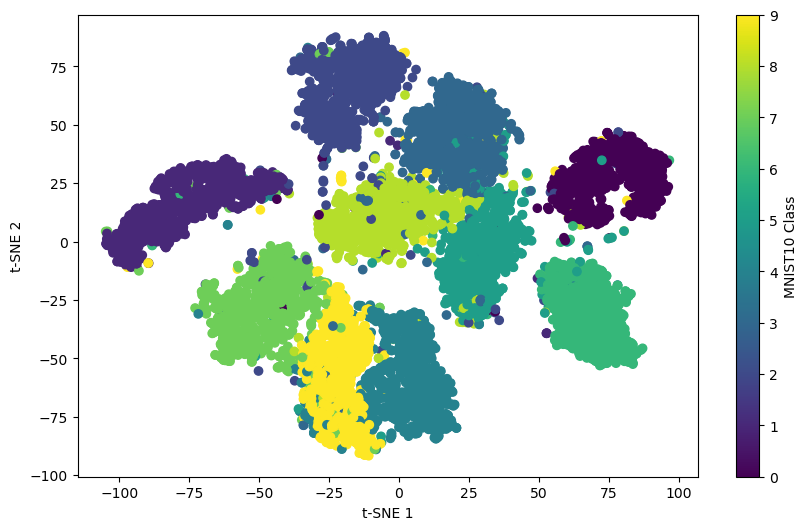

In [9]:
# Extract features using the trained autoencoder
from sklearn.manifold import TSNE
with torch.no_grad():
   features = []
   for i,(data, labels) in enumerate(test_loader):
       data = data.to(device)
       encoded = model.encoder(data)
       features.append(encoded.view(encoded.size(0), -1).cpu().numpy())
features = np.concatenate(features, axis=0)

# Apply TSNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=33, learning_rate=1000, init='pca')
tsne_features = tsne.fit_transform(features)

# Plot the TSNE results without label
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot the TSNE results with label
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=test_data.targets, cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='MNIST10 Class')
plt.show()

UMAP

/tmp/ipykernel_3753825/516853797.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(umap_features[:, 0], umap_features[:, 1], cmap='viridis')


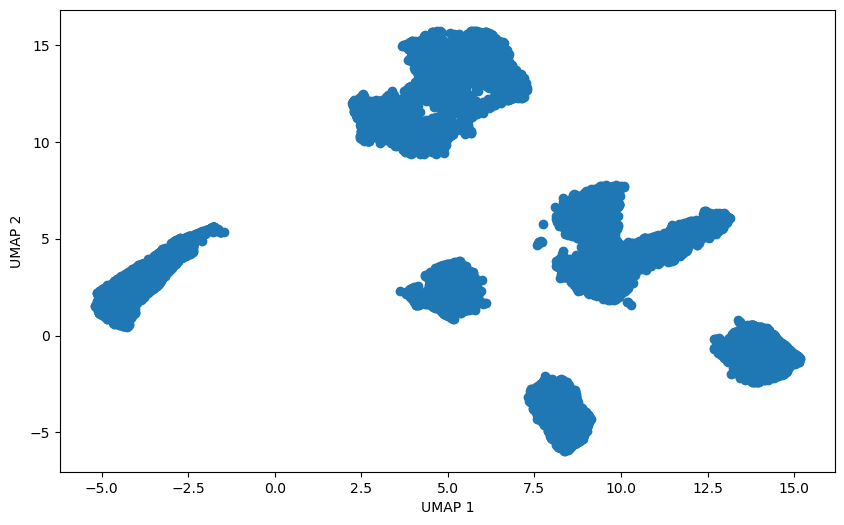

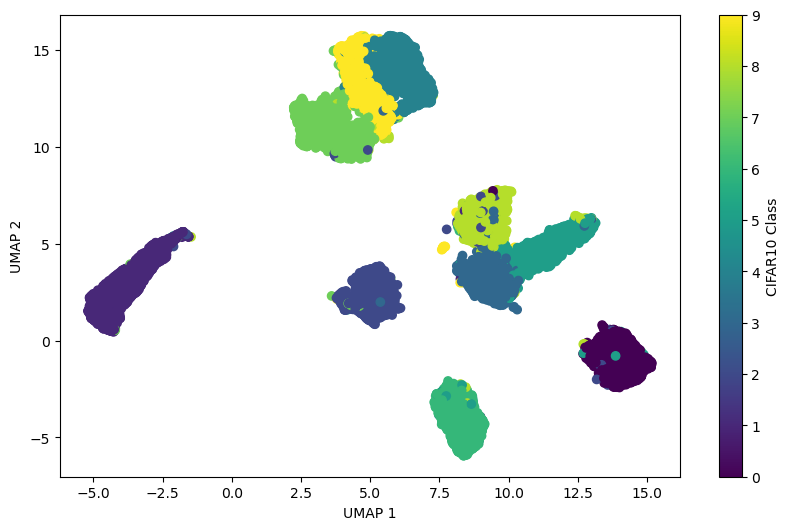

In [10]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Apply UMAP for dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_features = umap_model.fit_transform(features)

# Plot the UMAP results without label
plt.figure(figsize=(10, 6))
plt.scatter(umap_features[:, 0], umap_features[:, 1], cmap='viridis')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Plot the UMAP results with label
plt.figure(figsize=(10, 6))
plt.scatter(umap_features[:, 0], umap_features[:, 1], c=test_data.targets, cmap='viridis')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='CIFAR10 Class')
plt.show()